# **Besoin client 3 : Modèle de Prédiction du Type d'Implantation d'une Borne VE**

<br>

---


**Objectif :** Développer un modèle d'intelligence artificielle capable de prédire le type d’implantation d’une borne


---

<br>

Il faut donc prédire la colonne `implantation_station` (composée de 5 classes : voirie, parking privé à usage public, parking public, station dédiée recharge rapide, parking privé réservé clientèle) à partir des caractéristiques techniques et géographiques d'une borne de recharge électrique.

<br>

**Etapes :**
1. Préparation et exploration des données
2. Apprentissage supervisé pour la classification
3. Métriques pour la classification
4. Synthèse

<br>

# Librairies

In [1]:
import pandas as pd # manipulation de tableaux de données (DataFrames)
import numpy as np # calculs numériques, tableaux
import matplotlib.pyplot as plt # graphiques de base
import seaborn as sns # graphiques statistiques plus jolis
import joblib # sauvegarder/charger des modèles

# Prétraitement des données
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler # encode colonne catégorielle en entiers et normalise les valeurs
from sklearn.pipeline import Pipeline # chaîne des étapes de traitement en un seul objet
from sklearn.compose import ColumnTransformer # applique des traitements différents selon les colonnes
from sklearn.impute import SimpleImputer # remplace les valeurs manquantes (par la moyenne, médiane…)

# Modèles
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # forêt d'arbres de décision, arbres entraînés séquentiellement
from sklearn.linear_model import LogisticRegression # modèle linéaire pour la classification
from sklearn.tree import DecisionTreeClassifier # arbre de décision simple

# Évaluation et sélection
from sklearn.model_selection import StratifiedShuffleSplit  # découpage aléatoire stratifié — respecte les proportions des classes
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold # découpe les données en jeu d'entraînement / test, cherche les meilleurs hyperparamètres par validation croisée, validation croisée en conservant les proportions de classes
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, # % de bonnes prédictions, équilibre précision/rappel, tableau complet des métriques par classe
    confusion_matrix, ConfusionMatrixDisplay # matrice des vrais/faux positifs & négatifs, affichage graphique de cette matrice
)
from sklearn.metrics import precision_score, recall_score # importation des métriques précision et rappel

import warnings
warnings.filterwarnings('ignore')  # masquer les avertissements parasites

# Chargement des Données

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/exportIA.csv')
df.head()

Mounted at /content/drive


,Unnamed: 0,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,...,datagouv_resource_id,datagouv_organization_or_owner,created_at,long,lat,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified
0,1,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
1,2,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490003,ies2024111385490003,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.572327,16.237882,97122.0,baie-mahault,True,True,False
2,3,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
3,4,syndicat mixte d'electricite de la guadeloupe ...,200010759.0,ep-energie@symeg.net,g-mob,contact@gmob.fr,+590590325142,gmob,frgobpies2024111385490004,ies2024111385490004,...,df592154-7616-4c01-9d89-6521e0011467,g-mob,2025-10-06t16:44:59.145000+00:00,-61.636493,16.271696,97129.0,lamentin,True,True,False
4,5,zetra distribution,895193019.0,contact@zetra.com,zetra distribution sas,contact@zetra.com,0170946050,zetra,frzetpmeura,NaN,...,fe8d0b39-4814-4bf1-9601-16e1dea20fa8,zetra-distribution,2025-06-17t15:36:54.011000+00:00,4.799711,48.967183,21190.0,tailly,False,True,False


# I. Préparation des données

### 1. Exploration & justification des variables

#### 1.1 Analyse des valeurs manquantes

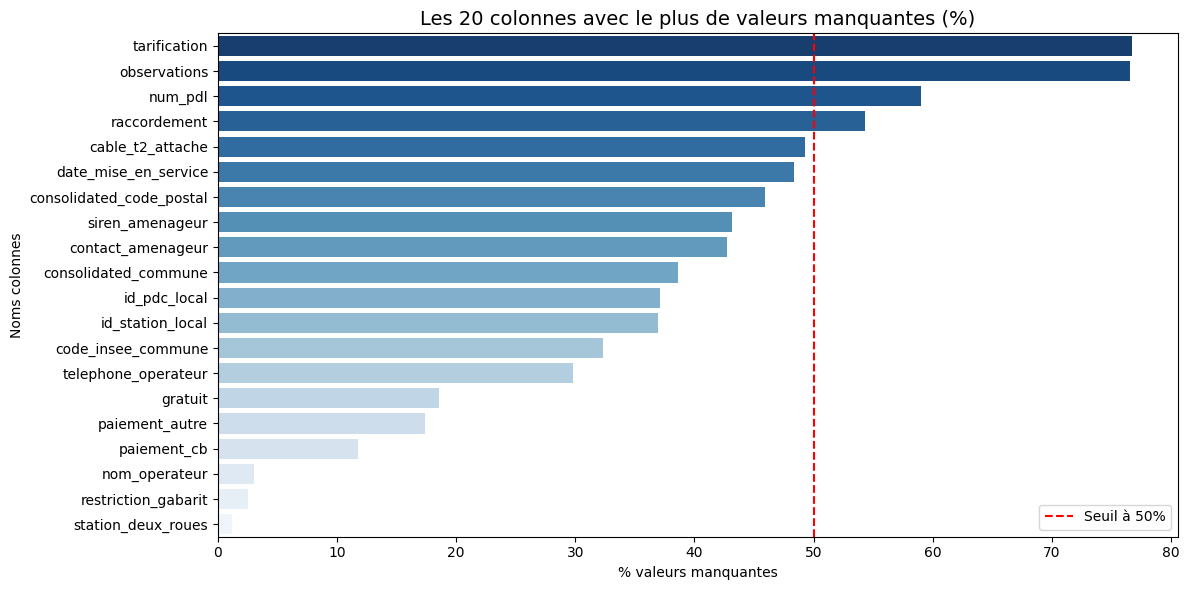

In [16]:
# Calcul du pourcentage de valeurs manquantes par colonne, trié du plus au moins manquant
missing = df.isnull().mean().sort_values(ascending=False) * 100

# On ne garde que les colonnes qui ont au moins une valeur manquante
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Noms colonnes', '% valeurs manquantes']

# Graphique
plt.figure(figsize=(12, 6))

# Barres horizontales des 20 colonnes les plus incomplètes
sns.barplot(data=missing_df.head(20), x='% valeurs manquantes', y='Noms colonnes', palette='Blues_r')
plt.title('Les 20 colonnes avec le plus de valeurs manquantes (%)', fontsize=14)

# Ligne rouge à 50% : seuil au-delà duquel on considère la colonne inutilisable
plt.axvline(50, color='red', linestyle='--', label='Seuil à 50%')
plt.legend()
plt.tight_layout()
plt.savefig('comparaisons_valeurs_manquantes.png')
plt.show()

Colonnes à exclure (trop vides pour être fiables car plus de 50% de valeurs manquantes) :
<br>
`tarification` `observations` `num_pdl` `raccordement`

#### 1.2 Justification et sélection des variables

**Variable : Type / Justification**
<br>
`nbre_pdc` : Numérique / Nombre de points de charge sur la station — corrélé à l'envergure de l'installation  
`puissance_nominale` : Numérique / Puissance max disponible (kW) — distingue recharge rapide vs lente  
`prise_type_ef` : Booléen / Prise EF (prise domestique)  
`prise_type_2` : Booléen / Prise T2 (standars européen)  
`prise_type_combo_ccs` : Booléen / Prise combo CCS (charge rapide)  
`prise_type_chademo` : Booléen / prise CHAdeMO (charge rapide, norme japonaise)  
`prise_type_autre` : Booléen / Autres types de prises  
`paiement_acte` : Booléen / Paiement possible sans abonnement — liés aux espaces publics  
`paiement_cb` : Booléen / Paiement CB accepté
`reservation` : Booléen / Réservation possible de la borne — usage privé / entreprise  
`station_deux_roues` : Booléen / Station adaptée aux 2-roues électriques — lié à la voirie  
`condition_acces` : Catégoriel / Accès libre, réservé, privé,... — discriminant fort  
`accessibilite_pmr` : Catégoriel / Accessibilité aux personnes à mobilité réduite — infrastructure publique  
`long` / `lat` : Numérique / Coordonnées GPS de la station — contexte géographique  


In [4]:
# Sélection des variables (features) utilisées pour l'entraînement

# Variables numériques
FEATURES_NUM = ['nbre_pdc', 'puissance_nominale', 'long', 'lat']

# Variables booléennes (0 ou 1)
FEATURES_BOOL = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo',
                'prise_type_autre', 'paiement_acte', 'paiement_cb', 'reservation', 'station_deux_roues']

# Variables catégorielles
FEATURES_CAT = ['condition_acces', 'accessibilite_pmr']

# Variable cible (target) —> ce que le modèle doit prédire
TARGET = 'implantation_station'  # ex : voirie, parking, centre commercial,...

# Concaténation de toutes les features
ALL_FEATURES = FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT

15 variables sélectionnées sur 53 colonnes :
   - Numériques : `nbre_pdc` `puissance_nominale` `long` `lat`
   - Booléennes : `prise_type_ef` `prise_type_2` `prise_type_combo_ccs` `prise_type_chademo` `prise_type_autre` `paiement_acte` `paiement_cb` `reservation` `station_deux_roues`
   - Catégorielles : `condition_acces` `accessibilite_pmr`

#### 1.3 Visualisation de la distribution de la cible

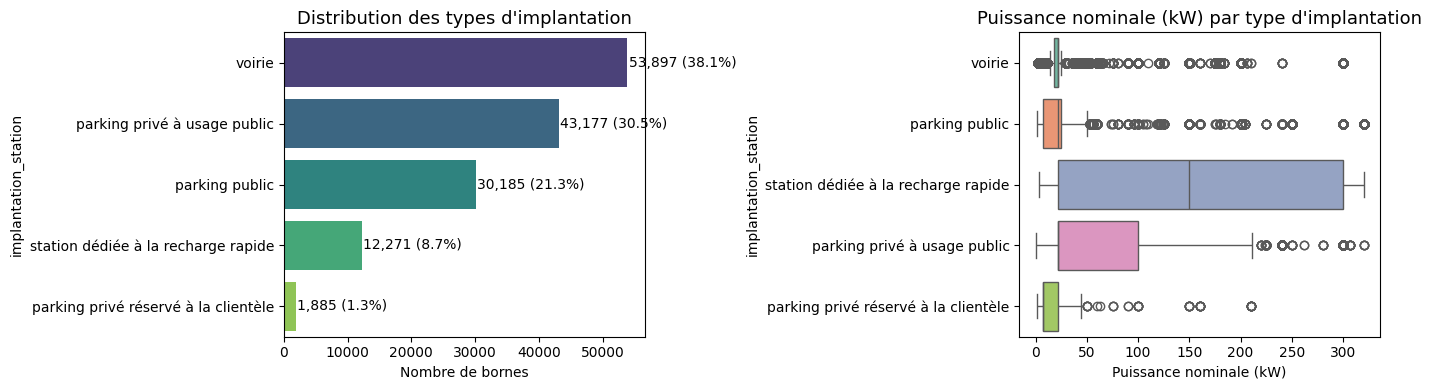

In [17]:
# Visualisation de la variable cible (implantation_station) et de son lien avec la puissance

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # pour mettre les 2 graphiques côte à côte

# Graphique 1 : Distribution de la variable cible
counts = df[TARGET].value_counts()  # compte le nombre de bornes par type d'implantation
sns.barplot(x=counts.values, y=counts.index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution des types d\'implantation', fontsize=13)
axes[0].set_xlabel('Nombre de bornes')

# Affiche le nombre et le pourcentage au bout de chaque barre
for i, v in enumerate(counts.values):
    axes[0].text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center')

# Graphique 2 : Puissance nominale par type d'implantation
# On exclut le top 1% des puissances pour éviter que les valeurs extrêmes rendent le graphique illisible
df_plot = df[df['puissance_nominale'] < df['puissance_nominale'].quantile(0.99)]

# boxplot par type d'implantation, montre la distribution de la puissance (médiane, écart interquartile, valeurs extrêmes)
sns.boxplot(data=df_plot, y=TARGET, x='puissance_nominale', palette='Set2', ax=axes[1])
axes[1].set_title('Puissance nominale (kW) par type d\'implantation', fontsize=13)
axes[1].set_xlabel('Puissance nominale (kW)')

plt.tight_layout()  # évite les chevauchements entre les deux graphiques
plt.savefig('implantation_puissance.png')
plt.show() # affiche tout

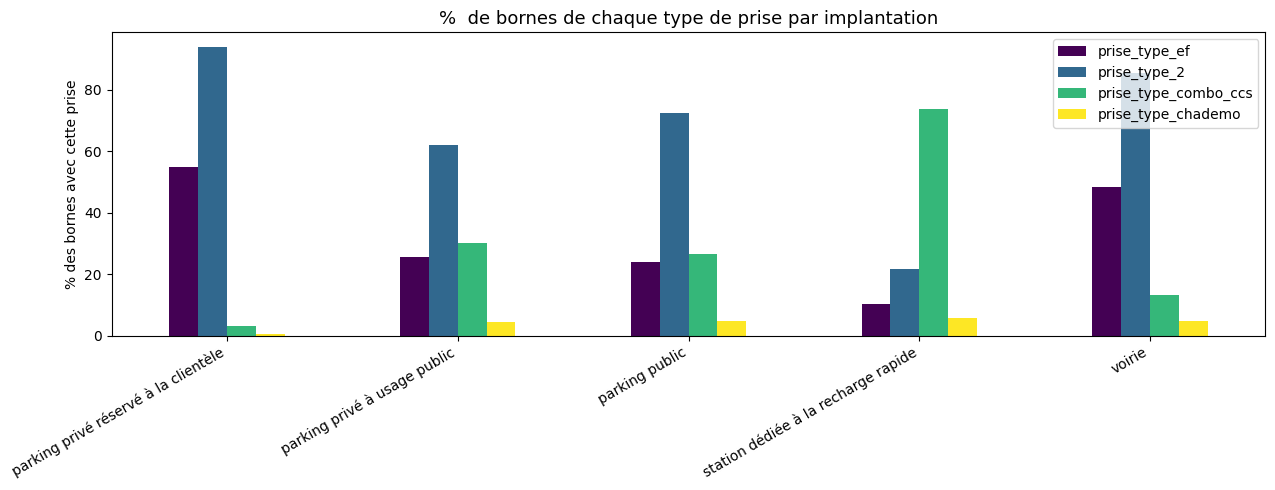

In [18]:
# Analyse des types de prises disponibles selon le type d'implantation

# colonnes correspondant aux types de prises
prise_cols = ['prise_type_ef', 'prise_type_2', 'prise_type_combo_ccs', 'prise_type_chademo']

# copie du dataframe pour ne pas modifier l'original
df_prise = df.copy()

# normalisation des valeurs booléennes : 'True'/'False' (texte) ou True/False (booléen) normalisés en booléens Python
for c in prise_cols:
    df_prise[c] = df_prise[c].map({'True': True, 'False': False, True: True, False: False})

# pour chaque type d'implantation, calcule la moyenne de chaque type de prise (proportion de True = % de bornes équipées) multiplié par 100 pour avoir un pourcentage
prise_by_impl = df_prise.groupby(TARGET)[prise_cols].mean() * 100

# Graphique
prise_by_impl.plot(kind='bar', figsize=(13, 5), colormap='viridis') # barres groupées (1 couleur par type de prise, une barre par implantation)

plt.title('%  de bornes de chaque type de prise par implantation', fontsize=13)
plt.ylabel('% des bornes avec cette prise')
plt.xlabel('') # pas de label sur l'axe X, les noms d'implantation suffisent
plt.xticks(rotation=30, ha='right') # incline les étiquettes pour éviter les chevauchements
plt.legend(loc='upper right') # légende des types de prises en haut à droite
plt.tight_layout()
plt.savefig('bornes_prises_par_implantation.png')
plt.show()

### 2. Prétraitement des données

In [7]:
# extraction du sous-ensemble utile : (les colonnes features + la cible)
df_model = df[ALL_FEATURES + [TARGET]].copy()

# suppression des lignes où la valeur cible est manquante
df_model = df_model.dropna(subset=[TARGET])
print(f'Lignes après suppression cible manquante : {len(df_model)}')

# normalisation des colonnes booléennes : on uniformise tout en 0 ou 1 pour que le modèle puisse les utiliser
for col in FEATURES_BOOL:
    df_model[col] = df_model[col].map(
        {True: 1, False: 0, 'True': 1, 'False': 0, 'true': 1, 'false': 0}
    ).fillna(0).astype(int) # les valeurs non reconnues deviennent 0

# nettoyage des variables catégorielles :
# - fillna('inconnu') : remplace les valeurs manquantes par 'inconnu'
# - str.strip() : supprime les espaces en début/fin
# - str.lower() : met tout en minuscules pour éviter les doublons ('Libre' ≠ 'libre')
def normalize_cat(series):
    return series.fillna('inconnu').str.strip().str.lower()

for col in FEATURES_CAT:
    df_model[col] = normalize_cat(df_model[col])

# encodage de la variable cible : le modèle ne peut pas travailler avec du texte, on convertit chaque classe en entier
le_target = LabelEncoder()
df_model['target_encoded'] = le_target.fit_transform(df_model[TARGET])

# affichage de la correspondance entier <-> nom de classe
print(f'\nClasses encodées :')
for i, c in enumerate(le_target.classes_):
    print(f'  {i} → {c}')

# sauvegarde du LabelEncoder pour pouvoir retrouver les noms de classes lors des prédictions futures (pour décoder les résultats)
joblib.dump(le_target, 'label_encoder_target.pkl')
print('\nlabel_encoder_target.joblib sauvegardé')

Lignes après suppression cible manquante : 141415

Classes encodées :
  0 → parking privé réservé à la clientèle
  1 → parking privé à usage public
  2 → parking public
  3 → station dédiée à la recharge rapide
  4 → voirie

label_encoder_target.joblib sauvegardé


In [8]:
# séparation des features (X) et de la cible (y)
X = df_model[ALL_FEATURES] # les colonnes d'entrée du modèle
y = df_model['target_encoded'] # la colonne à prédire (encodée en entiers)

# découpage train / test : 80% des données pour entraîner le modèle, 20% pour l'évaluer
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
# stratify=y : garantit que chaque classe est représentée proportionnellement dans les 2 ensembles (important si les classes sont déséquilibrées)
)
print(f'Train : {X_train.shape} | Test : {X_test.shape}')


# Traitement des variables numériques
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # remplace les valeurs manquantes par la médiane de la colonne
    ('scaler', StandardScaler()) # centre et réduit (moyenne=0, écart-type=1), ramène toutes les valeurs sur la même échelle
])

# Traitement des variables booléennes
bool_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)) # remplace les valeurs manquantes par 0 (= False par défaut)
])

# Traitement des variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='inconnu')), # remplace les valeurs manquantes par 'inconnu'
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)) # convertit le texte en nombre, unknown_value=-1 évite une erreur si une valeur jamais vue apparaît plus tard
])

# applique le bon traitement selon le type de chaque colonne (num / bool / cat) en une seule fois
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, FEATURES_NUM),
    ('bool', bool_transformer, FEATURES_BOOL),
    ('cat', categorical_transformer, FEATURES_CAT)
])

preprocessor.fit(X_train) # apprend les statistiques sur le train seulement
X_train_proc = preprocessor.transform(X_train) # applique au train
X_test_proc  = preprocessor.transform(X_test) # applique au test avec les mêmes stats

# Sauvegarde du préprocesseur (pour appliquer exactement les mêmes transformations sur de nouvelles données en production)
joblib.dump(preprocessor, 'preprocessor.pkl')
print(f'Shape X_train_proc : {X_train_proc.shape}') # dimensions du tableau transformé pour vérifier que tout s'est bien passé

Train : (113132, 15) | Test : (28283, 15)
Shape X_train_proc : (113132, 15)


# II- Apprentissage supervisé pour la classification

## 1. Choix du modèle & entraînement

<u>**Comparaison des trois algorithmes**</u>

**Objectif :** évaluer 3 algorithmes dans leur configuration de base (sans optimisation) pour choisir le plus prometteur avant le GridSearchCV.

<br>

**Algorithme : Avantages / Inconvénients**  
  
`Random Forest` : Robuste, gère les non-linéarités, peu sensible aux outliers, feature importance / Moins interprétable qu'un arbre simple  
  
`Gradient Boosting` : Très performant, bon biais-variance / Plus lent, sensible aux hyperparamètres  
  
`Régression Logistique` : Rapide, interprétable / Suppose une relation linéaire  

> **Random Forest** est notre modèle principal : il excelle sur des données mixtes (numériques + catégorielles), résiste aux valeurs aberrantes, et fournit une **feature importance** utile pour la justification.

Random Forest             | Accuracy=0.9719 | F1=0.9719 | 10.3s
Gradient Boosting         | Accuracy=0.8072 | F1=0.8054 | 83.2s
Logistic Regression       | Accuracy=0.5947 | F1=0.5814 | 8.0s


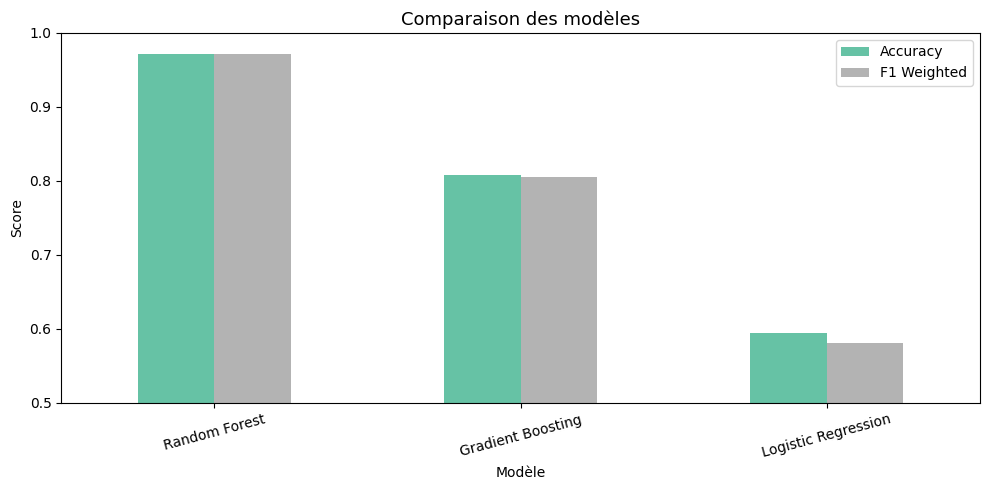

                     Accuracy  F1 Weighted  Temps (s)
Modèle                                               
Random Forest        0.971891     0.971878       10.3
Gradient Boosting    0.807234     0.805407       83.2
Logistic Regression  0.594739     0.581369        8.0


In [19]:
from time import time

# dictionnaire contenant les modèles qu'on va entraîner puis comparer pour garder le plus performant
models = {
    # 100 arbres en parallèle
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), # n_jobs=-1 utilise tous les cœurs CPU pour accélérer l'entraînement

    # 100 arbres en séquence, chaque arbre corrige le précédent
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42), # random_state=42 : résultats identiques à chaque exécution

    # modèle simple et rapide
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1), # max_iter=1000 : augmenté pour que la régression logistique converge sur nos données
}

results = []  # pour stocker les métriques de chaque modèle

for name, model in models.items():

    # mesure du temps d'entraînement
    t0 = time()
    model.fit(X_train_proc, y_train)  # entraînement sur les données prétraitées
    t1 = time()

    # prédiction sur le jeu de TEST
    y_pred = model.predict(X_test_proc)

    # % de bonnes prédictions —> rapide à lire mais trompeur si les classes sont déséquilibrées
    acc = accuracy_score(y_test, y_pred)

    # F1 pondéré —> métrique principale : mesure la qualité de chaque classe et fait une moyenne selon leur proportion dans le dataset
    f1  = f1_score(y_test, y_pred, average='weighted')

    # stockage des résultats dans la liste
    results.append({
        'Modèle': name,
        'Accuracy': acc,
        'F1 Weighted': f1,
        'Temps (s)': round(t1 - t0, 1)
    })

    # affichage immédiat pour suivre la progression (utile si l'entraînement est long)
    print(f'{name:25s} | Accuracy={acc:.4f} | F1={f1:.4f} | {t1-t0:.1f}s')

# conversion en DataFrame pour faciliter l'affichage et la visualisation
results_df = pd.DataFrame(results).set_index('Modèle')

# graphique pour comparer visuellement les performances des algos
results_df[['Accuracy', 'F1 Weighted']].plot(
    # Accuracy : taux de bonnes prédictions
    # F1 Weighted : qualité du modèle
    kind='bar',
    figsize=(10, 5),
    colormap='Set2',
    rot=15
)
plt.title('Comparaison des modèles', fontsize=13)
plt.ylim(0.5, 1.0) # axe Y limité à [0.5, 1.0] pour mieux visualiser les écarts
plt.ylabel('Score')
plt.tight_layout() # ajuste automatiquement les marges pour éviter les coupures
plt.savefig('comparaison_modele.png')
plt.show()

# affichage du tableau récapitulatif (scores + temps d'entraînement)
print(results_df)

## 2. Optimisation — GridSearchCV sur Random Forest

**Justification des métriques :**
- **Accuracy** : proportion de prédictions correctes —> intuitive mais insuffisante si les classes sont déséquilibrées
- **F1 Weighted** : moyenne des F1 par classe pondérée par le support —> robuste au déséquilibre de classes, c'est notre métrique principale
- **Matrice de confusion** : visualise les erreurs entre classes

In [10]:
# Recherche des meilleurs hyperparamètres pour le Random Forest

# on prend seulement 20% du train pour que le GridSearch soit plus rapide
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=42) # StratifiedShuffleSplit respecte les proportions des classes dans le sous-ensemble
for train_idx, _ in sss.split(X_train_proc, y_train):
    X_gs = X_train_proc[train_idx]
    y_gs = y_train.iloc[train_idx]

print(f'Taille du sous-ensemble pour GridSearch : {X_gs.shape}')

# combinaisons de réglages à tester (2×3×2×2×2 = 48 combinaisons)
param_grid = {
    'n_estimators': [100, 200], # nombre d'arbres
    'max_depth': [None, 10, 20], # profondeur max de chaque arbre (None = illimité)
    'min_samples_split': [2, 5], # nb min d'exemples pour diviser un nœud
    'min_samples_leaf': [1, 2], # nb min d'exemples dans une feuille finale
    'class_weight': [None, 'balanced'] # 'balanced' compense le déséquilibre des classes
}

# Validation croisée en 5 blocs
# chaque combinaison est évaluée 5 fois sur des portions différentes du sous-ensemble -> score plus fiable qu'un simple split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV teste les 48 combinaisons × 5 blocs = 240 entraînements et garde la meilleure combinaison
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_weighted', # métrique utilisée pour comparer les combinaisons
    cv=cv,
    n_jobs=-1, # utilise tous les cœurs CPU pour accélérer
    verbose=2, # affiche la progression dans la console
    refit=True # réentraîne automatiquement sur la meilleure combinaison
)

print('Lancement du GridSearchCV...')
grid_search.fit(X_gs, y_gs)

# affichage des meilleurs réglages trouvés et du score obtenu
print(f'\nMeilleurs hyperparamètres :')
print(grid_search.best_params_)
print(f'\nMeilleur score F1 (CV) : {grid_search.best_score_:.4f}')

Taille du sous-ensemble pour GridSearch : (22626, 15)
Lancement du GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Meilleurs hyperparamètres :
{'class_weight': None, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Meilleur score F1 (CV) : 0.9156


Le GridSearch permet de trouver les meilleurs réglages pour le modèle (les hyperparamètres).

# III- Métriques pour la classification

## 1. Évaluation du meilleur modèle

In [11]:
# récupération du meilleur modèle trouvé par le GridSearch
best_model = grid_search.best_estimator_

# ré-entraînement sur le train COMPLETavec les meilleurs hyperparamètres
best_model.fit(X_train_proc, y_train)

# prédictions sur le test avec le modèle optimisé
y_pred_best = best_model.predict(X_test_proc)

# calcul des métriques sur le test
acc_best = accuracy_score(y_test, y_pred_best)
f1_best  = f1_score(y_test, y_pred_best, average='weighted')

print(f'=== Résultats du meilleur modèle (Random Forest optimisé) ===')
print(f'Accuracy : {acc_best:.4f}')
print(f'F1 Weighted : {f1_best:.4f}')
print()

# rapport détaillé : précision, rappel et F1 pour chaque classe individuellement
# target_names=le_target.classes_ remplace les numéros (0,1,2...) par les vrais noms
print('=== Rapport de classification ===')
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

=== Résultats du meilleur modèle (Random Forest optimisé) ===
Accuracy : 0.9720
F1 Weighted : 0.9720

=== Rapport de classification ===
                                      precision    recall  f1-score   support

parking privé réservé à la clientèle       0.97      0.96      0.97       377
        parking privé à usage public       0.97      0.98      0.97      8636
                      parking public       0.96      0.95      0.95      6037
 station dédiée à la recharge rapide       0.99      0.99      0.99      2454
                              voirie       0.98      0.98      0.98     10779

                            accuracy                           0.97     28283
                           macro avg       0.97      0.97      0.97     28283
                        weighted avg       0.97      0.97      0.97     28283



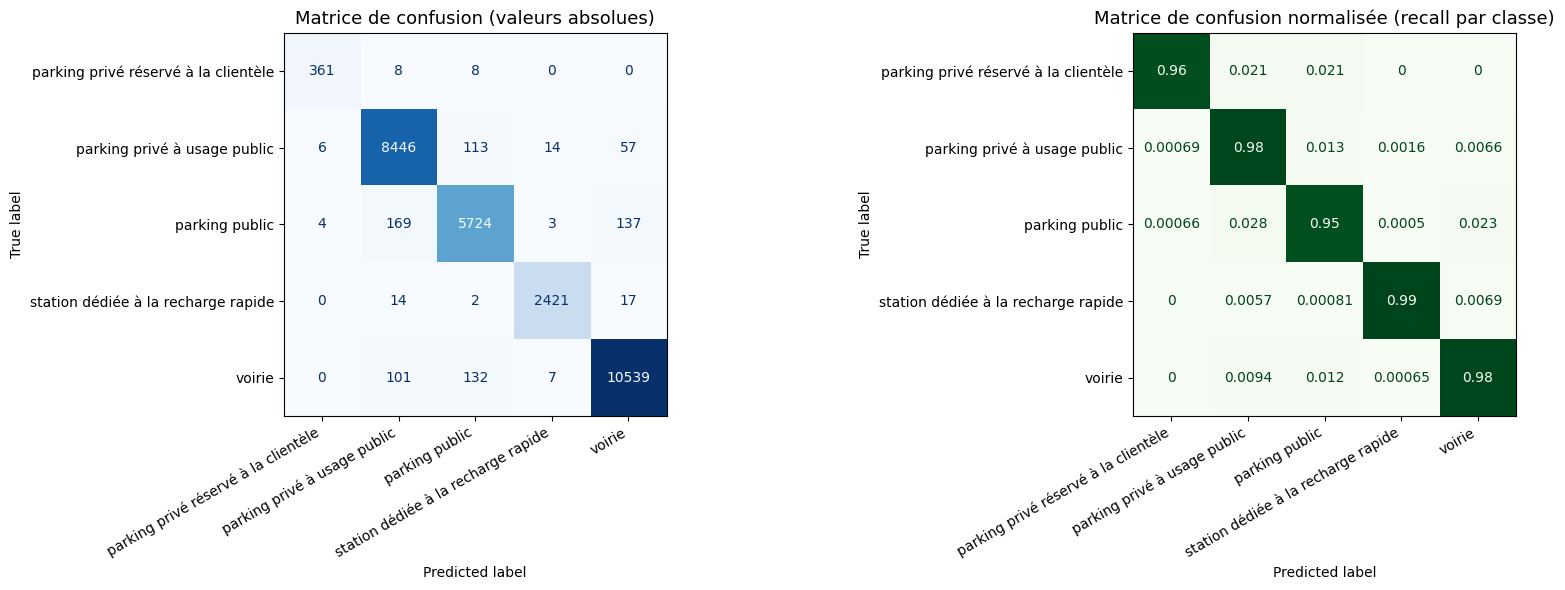

In [20]:
# matrice de confusion
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# matrice absolue
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=13)
axes[0].set_xticklabels(le_target.classes_, rotation=30, ha='right')

# matrice normalisée
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le_target.classes_)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matrice de confusion normalisée (recall par classe)', fontsize=13)
axes[1].set_xticklabels(le_target.classes_, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('matrices_confusion.png')
plt.show()

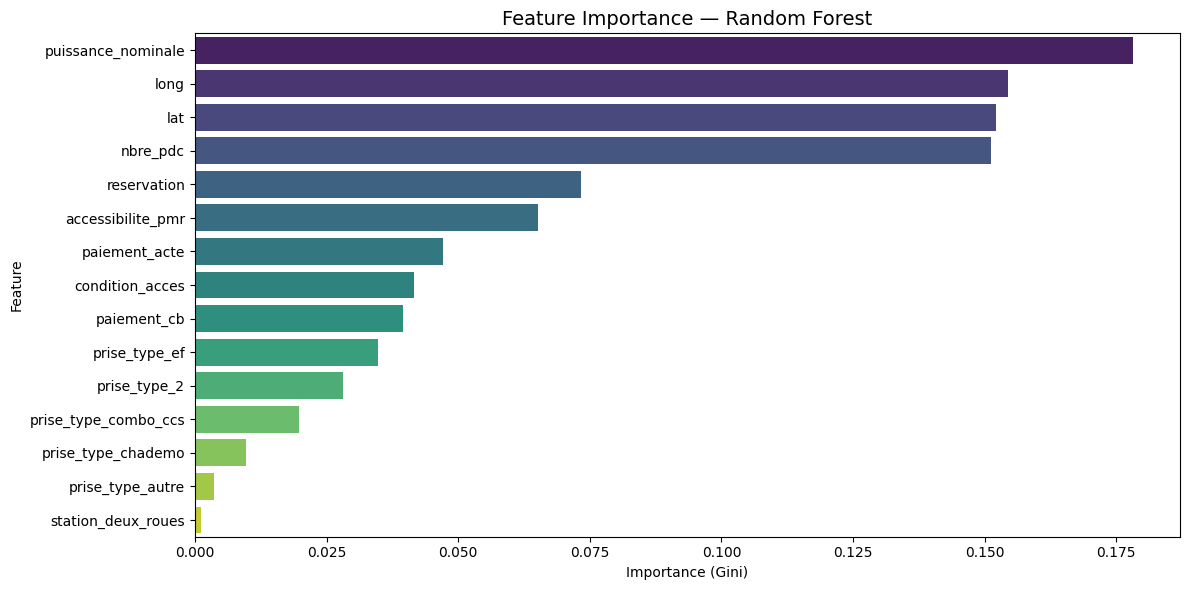


Tableau des importances :
             Feature  Importance
  puissance_nominale    0.178183
                long    0.154406
                 lat    0.152237
            nbre_pdc    0.151150
         reservation    0.073376
   accessibilite_pmr    0.065166
       paiement_acte    0.047074
     condition_acces    0.041704
         paiement_cb    0.039463
       prise_type_ef    0.034742
        prise_type_2    0.028194
prise_type_combo_ccs    0.019729
  prise_type_chademo    0.009686
    prise_type_autre    0.003702
  station_deux_roues    0.001188


In [21]:
# liste de toutes les features dans le même ordre que le préprocesseur les a traitées
feature_names = FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT

# scores d'importance calculés par le Random Forest, chaque valeur représente la contribution de la variable à la qualité des prédictions
importances = best_model.feature_importances_

# tableau feature <-> importance des entrées, trié du plus au moins important
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

# graphique : barres horizontales, la plus importante en haut
plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance (Gini)')  # score Gini : mesure à quel point la variable aide à séparer les classes
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# affichage du tableau complet avec les valeurs exactes
print('\nTableau des importances :')
print(fi_df.to_string(index=False))

Tableau des métriques par classe
                              Classe  Precision   Recall  F1 Score  Support
 station dédiée à la recharge rapide   0.990184 0.986553  0.988365     2454
                              voirie   0.980372 0.977734  0.979052    10779
        parking privé à usage public   0.966583 0.977999  0.972257     8636
parking privé réservé à la clientèle   0.973046 0.957560  0.965241      377
                      parking public   0.957351 0.948153  0.952730     6037


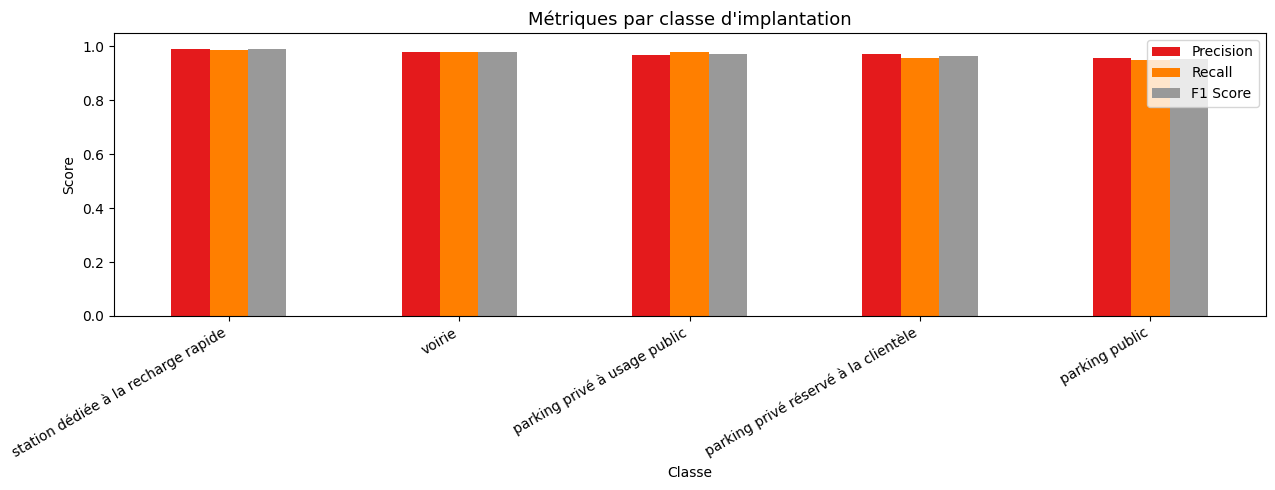

In [22]:
# tableau récapitulatif avec les 4 métriques pour chaque classe :
metrics_table = pd.DataFrame({
    'Classe':     le_target.classes_,
    'Precision':  precision_score(y_test, y_pred_best, average=None), # quand le modèle prédit cette classe, a-t-il raison ?
    'Recall':     recall_score(y_test, y_pred_best, average=None), # parmi les vrais exemples de cette classe, combien a-t-il trouvé ?
    'F1 Score':   f1_score(y_test, y_pred_best, average=None), # moyenne entre précision et rappel
    'Support':    cm.sum(axis=1)  # nombre d'exemples réels de cette classe dans le test, somme des lignes de la matrice de confusion = effectif réel
    # calcule la métrique séparément pour chaque classe (pas de moyenne globale)
})

# tri par F1 Score décroissant : les classes les mieux prédites en premier
metrics_table = metrics_table.sort_values('F1 Score', ascending=False)

print('Tableau des métriques par classe')
print(metrics_table.to_string(index=False))

# graphique : comparaison des 3 métriques pour chaque classe
metrics_table_plot = metrics_table.set_index('Classe')[['Precision', 'Recall', 'F1 Score']]
metrics_table_plot.plot(kind='bar', figsize=(13, 5), colormap='Set1')
# barres groupées : 3 barres par classe (une par métrique)

plt.title('Métriques par classe d\'implantation', fontsize=13)
plt.ylabel('Score')
plt.ylim(0, 1.05) # axe Y entre 0 et 1.05 pour laisser de l'espace au dessus
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('metrique_par_classe.png')
plt.show()

## 2. Sauvegarde des modèles

In [15]:
# sauvegarde du meilleur modèle
joblib.dump(best_model, 'best_model_rf.pkl')
# sauvegarde du préprocesseur (déjà fait plus haut, mais on confirme)
joblib.dump(preprocessor, 'preprocessor.pkl')
# sauvegarde du LabelEncoder
joblib.dump(le_target, 'label_encoder_target.pkl')
# sauvegarde de la liste des features dans l'ordre
joblib.dump(ALL_FEATURES, 'feature_names.pkl')

print('Fichiers sauvegardés :')
print('-> best_model_rf.pkl')
print('-> preprocessor.pkl')
print('-> label_encoder_target.pkl')
print('-> feature_names.pkl')

Fichiers sauvegardés :
-> best_model_rf.pkl
-> preprocessor.pkl
-> label_encoder_target.pkl
-> feature_names.pkl


# IV. Synthèse

### Récapitulatif

| Étape | Décision | Justification |
|---|---|---|
| **Variables** | 15 features (num, bool, cat) | Pertinence métier + faible taux de valeurs manquantes |
| **Prétraitement** | Imputation médiane/constante + StandardScaler + OrdinalEncoder | Adapté aux types de données mixtes |
| **Algorithme** | Random Forest | Robustesse, feature importance, multiclasse natif |
| **Optimisation** | GridSearchCV 5-fold stratifié | Exploration exhaustive, respect de la distribution des classes |
| **Métrique principale** | F1 Weighted | Robuste au déséquilibre de classes (voirie >> parking privé clientèle) |
| **Fichiers sauvegardés** | 4 fichiers .joblib | Prédiction sans réentraînement |

### Fichiers produits
- `best_model_rf.pkl` : Modèle Random Forest optimisé
- `preprocessor.pkl` : Pipeline de prétraitement
- `label_encoder_target.pkl` : Encodeur de la cible
- `feature_names.pkl` : Ordre des features
